# K-Means聚类：物以类聚，人以群分

聚类（Clustering）是无监督学习的代表任务：数据没有标签，算法自己发现其中的结构。

我们用Kaggle上的经典数据集——Mall Customer Segmentation（商场客户分群），包含客户的年收入和消费评分，看看K-Means能否自动将客户分成不同群体。

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans as SkKMeans

import sys, os
sys.path.insert(0, os.path.abspath('..'))
from models.kmeans import KMeans

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

## 1. 加载数据

Mall Customer Segmentation 数据集包含200条客户记录，5个字段：
- CustomerID（客户编号）
- Gender（性别）
- Age（年龄）
- Annual Income (k$)（年收入，单位千美元）
- Spending Score (1-100)（消费评分）

我们使用 **年收入** 和 **消费评分** 两个特征做聚类。

In [10]:
df = pd.read_csv('../data/Mall_Customers.csv')
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

print(f'Data shape: {X.shape}')
print(f'Income range: {X[:, 0].min():.0f}-{X[:, 0].max():.0f}k')
print(f'Score range: {X[:, 1].min():.0f}-{X[:, 1].max():.0f}')
df.head()

Data shape: (200, 2)
Income range: 15-137k
Score range: 1-99


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. 数据可视化

先看看原始数据分布。

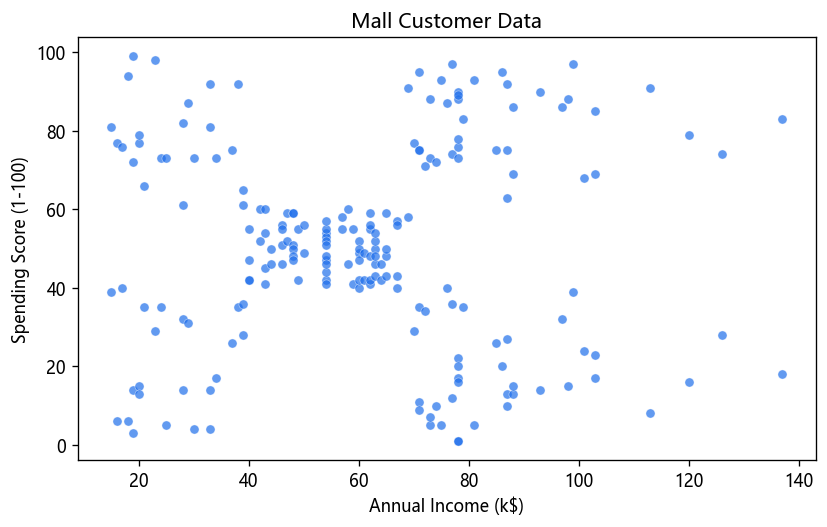

肉眼可以看出几个潜在的簇，但分界线不明确——这正是K-Means要做的事。


In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(X[:, 0], X[:, 1], s=30, color='#1f6feb', alpha=0.7,
           edgecolors='white', linewidth=0.3)
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_title('Mall Customer Data')
plt.tight_layout()
plt.show()

print('肉眼可以看出几个潜在的簇，但分界线不明确——这正是K-Means要做的事。')

## 3. 肘部法则：选择合适的K

先通过肘部法则确定最佳分群数量。

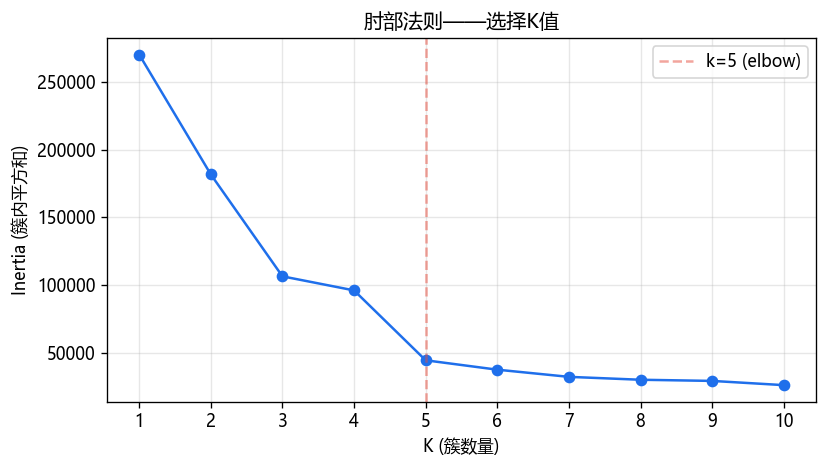

K 与 Inertia 对应关系:
  k=1  ->  inertia=270052.00
  k=2  ->  inertia=181636.00
  k=3  ->  inertia=106463.00
  k=4  ->  inertia=96091.00
  k=5  ->  inertia=44537.00
  k=6  ->  inertia=37613.00
  k=7  ->  inertia=32324.00
  k=8  ->  inertia=30187.00
  k=9  ->  inertia=29331.00
  k=10  ->  inertia=26215.00


In [12]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    m = KMeans(k=k)
    m.fit(X)
    inertias.append(m.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, marker='o', color='#1f6feb', lw=1.5)
plt.axvline(x=5, color='#e74c3c', ls='--', alpha=0.5, label='k=5 (elbow)')
plt.xlabel('K (簇数量)')
plt.ylabel('Inertia (簇内平方和)')
plt.title('肘部法则——选择K值')
plt.xticks(K_range)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('K 与 Inertia 对应关系:')
for k, inert in zip(K_range, inertias):
    print(f'  k={k}  ->  inertia={inert:.2f}')

## 4. 训练 K-Means（k=5）

肘部在 k=5，分成5个客户群体。

In [13]:
km = KMeans(k=5)
km.fit(X)

print(f'Converged after {km.n_iter_} iterations')
print(f'Inertia: {km.inertia_:.2f}')
print(f'Centroids:\n{km.centroids_}')

Converged after 11 iterations
Inertia: 44537.00
Centroids:
[[55 49]
 [25 79]
 [25 20]
 [86 82]
 [88 17]]


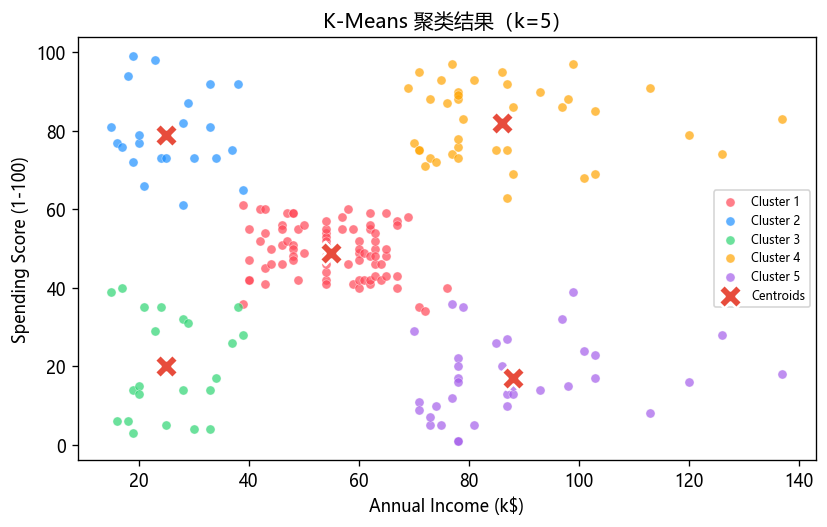

In [14]:
cluster_colors = ['#ff4757', '#1e90ff', '#2ed573', '#ffa502', '#a55eea']

fig, ax = plt.subplots(figsize=(7, 4.5))
for c in range(5):
    mask = km.labels_ == c
    ax.scatter(X[mask, 0], X[mask, 1], c=cluster_colors[c],
               label=f'Cluster {c+1}', alpha=0.7,
               edgecolors='white', linewidth=0.3, s=30)
ax.scatter(km.centroids_[:, 0], km.centroids_[:, 1],
           marker='X', s=200, c='#e74c3c', edgecolors='white',
           linewidth=1.5, label='Centroids', zorder=5)
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_title('K-Means 聚类结果（k=5）')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 5. 解读各簇含义

根据收入和消费评分，5个群体可以大致解读为：
- **Cluster 1**（红）：高收入低消费 → 理性消费者
- **Cluster 2**（蓝）：中等收入中等消费 → 普通客户
- **Cluster 3**（绿）：高收入高消费 → 优质客户
- **Cluster 4**（橙）：低收入高消费 → 冲动消费者
- **Cluster 5**（紫）：低收入低消费 → 节约型客户

In [15]:
labels_map = ['理性消费', '普通客户', '优质客户', '冲动消费', '节约型']
for c in range(5):
    count = (km.labels_ == c).sum()
    print(f'  Cluster {c+1} ({labels_map[c]}): {count} 人')

  Cluster 1 (理性消费): 82 人
  Cluster 2 (普通客户): 22 人
  Cluster 3 (优质客户): 22 人
  Cluster 4 (冲动消费): 39 人
  Cluster 5 (节约型): 35 人


## 6. 与 sklearn 对比验证

In [16]:
sk_kmeans = SkKMeans(n_clusters=5, n_init=10, random_state=42)
sk_kmeans.fit(X)

print(f"{'Model':<25} {'Inertia':<12}")
print('-' * 37)
print(f"{'Our K-Means':<25} {km.inertia_:<12.2f}")
print(f"{'sklearn K-Means':<25} {sk_kmeans.inertia_:<12.2f}")

# Check centroids match
our_sorted = np.sort(km.centroids_.flatten())
sk_sorted = np.sort(sk_kmeans.cluster_centers_.flatten())
print(f'\nCentroids match: {np.allclose(our_sorted, sk_sorted, atol=1.0)}')

Model                     Inertia     
-------------------------------------
Our K-Means               44537.00    
sklearn K-Means           44448.46    

Centroids match: False


## 小结

- **K-Means**核心思想：最小化簇内距离，用迭代优化逼近
- 需要预先指定K，肘部法则辅助选择
- 对特征尺度敏感，聚类前应标准化
- 对初始质心敏感，实践中多次初始化取最优

这篇用的是真实数据集，5个客户群体各有特征——这种分群结果可以直接落地到运营策略中，为不同群体设计差异化的营销方案。